In [41]:
!pip install matplotlib
!pip install scikit-learn
!pip install kmodes
!pip install openpyxl

In [27]:
# Run once: pip install kmodes scikit-learn matplotlib pandas openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from kmodes.kprototypes import KPrototypes

In [28]:
df = pd.read_excel(r"C:\Users\rahul\Downloads\Rural_vs_Urban_Consumer_Survey_EN_updated.xlsx")
df = df.dropna(how="all").reset_index(drop=True)
print(df.shape)
print(df.head())

(149, 10)
  Location Type  Gender Current Mobile Phone Brand Factors For Buying  \
0         Rural  Female                     Xiaomi             Other:   
1         Rural    Male                       IQOO     Specifications   
2         Rural  Female                     Xiaomi           Security   
3         Rural  Female                     Xiaomi              Price   
4         Rural    Male                     Xiaomi              Other   

  Preferred Purchase Channel   Age  Monthly Household Income  \
0                    Offline  49.0                     32900   
1   Online (Amazon/Flipkart)  21.0                     21000   
2   Online (Amazon/Flipkart)  50.0                     32200   
3   Online (Amazon/Flipkart)  30.0                     21100   
4   Online (Amazon/Flipkart)  34.0                     11000   

   Amount Spent on Previous Phone (₹)  \
0                               16300   
1                               19000   
2                               15300   
3 

In [29]:
df["Current Mobile Phone Brand"] = df["Current Mobile Phone Brand"].str.strip().replace({
    "Iqoo": "IQOO", "iQOO": "IQOO",
    "One plus": "OnePlus", "One Plus": "OnePlus",
    "Google pixel": "Google Pixel",
})

df["Factors For Buying"] = df["Factors For Buying"].str.strip().replace({
    "Other:": "Other", "Perfomance only": "Performance only",
})

print(df["Current Mobile Phone Brand"].unique())

['Xiaomi' 'IQOO' 'Apple' 'Realme' 'Samsung' 'Nokia 3310' 'Google Pixel'
 'Vivo' 'OnePlus' 'Nothing' 'Motorola']


In [30]:
print(df.isna().sum())          # check what's missing
df["Age"] = df["Age"].fillna(df["Age"].median())

Location Type                                     0
Gender                                            0
Current Mobile Phone Brand                        0
Factors For Buying                                0
Preferred Purchase Channel                        0
Age                                               1
Monthly Household Income                          0
Amount Spent on Previous Phone (₹)                0
Usage Before Replacing Previous Phone (Months)    0
Research Before Purchase (Days)                   0
dtype: int64


In [31]:
numeric_cols = [
    "Age",
    "Monthly Household Income",
    "Amount Spent on Previous Phone (₹)",
    "Usage Before Replacing Previous Phone (Months)",
    "Research Before Purchase (Days)",
]

categorical_cols = [
    "Location Type",
    "Gender",
    "Current Mobile Phone Brand",
    "Factors For Buying",
    "Preferred Purchase Channel",
]

In [32]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [34]:
model_cols = numeric_cols + categorical_cols
X = df_scaled[model_cols].to_numpy()
categorical_idx = list(range(len(numeric_cols), len(model_cols)))

k=2  cost=564.9
k=3  cost=474.7
k=4  cost=419.9
k=5  cost=387.6
k=6  cost=364.3
k=7  cost=336.4
k=8  cost=317.0


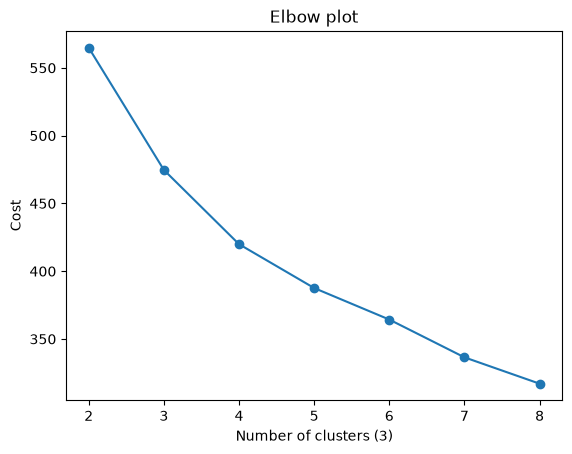

In [35]:
costs = []
k_range = range(2, 9)

for k in k_range:
    km = KPrototypes(n_clusters=k, init="Huang", n_init=5, random_state=42)
    km.fit_predict(X, categorical=categorical_idx)
    costs.append(km.cost_)
    print(f"k={k}  cost={km.cost_:.1f}")

plt.plot(list(k_range), costs, marker="o")
plt.xlabel("Number of clusters (3)")
plt.ylabel("Cost")
plt.title("Elbow plot")
plt.show()

In [36]:
K_FINAL = 3

model = KPrototypes(n_clusters=K_FINAL, init="Huang", n_init=10, random_state=42)
clusters = model.fit_predict(X, categorical=categorical_idx)

df["Cluster"] = clusters
print(df["Cluster"].value_counts().sort_index())

Cluster
0    46
1    64
2    39
Name: count, dtype: int64


In [42]:
# Numeric averages per cluster
print(df.groupby("Cluster")[numeric_cols].mean().round(1))

# Most common category per cluster
for col in categorical_cols:
    print(f"\n{col}:")
    print(df.groupby("Cluster")[col].agg(lambda s: s.mode().iloc[0]))

          Age  Monthly Household Income  Amount Spent on Previous Phone (₹)  \
Cluster                                                                       
0        34.2                   23204.3                             18723.9   
1        31.8                  117309.4                            130087.5   
2        45.5                   24794.9                             24666.7   

         Usage Before Replacing Previous Phone (Months)  \
Cluster                                                   
0                                                  65.5   
1                                                  21.5   
2                                                  64.3   

         Research Before Purchase (Days)  
Cluster                                   
0                                    7.8  
1                                   13.7  
2                                   24.2  

Location Type:
Cluster
0    Rural
1    Urban
2    Rural
Name: Location Type, dtype: object



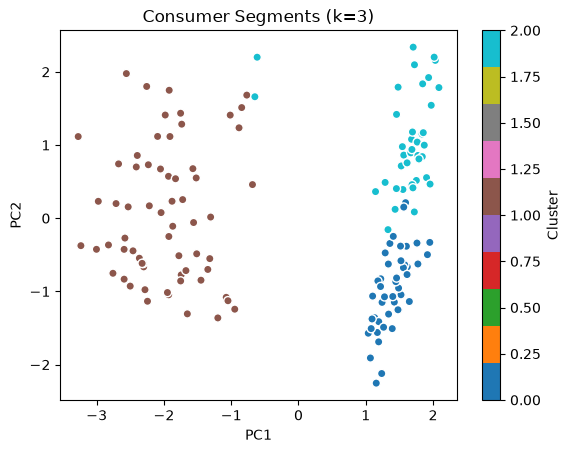

In [38]:
X_viz = pd.get_dummies(df_scaled[model_cols], columns=categorical_cols)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_viz)

plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="tab10", edgecolor="white")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Consumer Segments (k={K_FINAL})")
plt.colorbar(label="Cluster")
plt.show()

In [39]:
# Sanity check: does the story match the data?
print(df.groupby("Cluster")[numeric_cols].mean().round(1))
print(df.groupby("Cluster")["Preferred Purchase Channel"].value_counts(normalize=True))

          Age  Monthly Household Income  Amount Spent on Previous Phone (₹)  \
Cluster                                                                       
0        34.2                   23204.3                             18723.9   
1        31.8                  117309.4                            130087.5   
2        45.5                   24794.9                             24666.7   

         Usage Before Replacing Previous Phone (Months)  \
Cluster                                                   
0                                                  65.5   
1                                                  21.5   
2                                                  64.3   

         Research Before Purchase (Days)  
Cluster                                   
0                                    7.8  
1                                   13.7  
2                                   24.2  
Cluster  Preferred Purchase Channel
0        Online (Amazon/Flipkart)      0.543478
         

In [40]:
print(df.groupby("Cluster")["Amount Spent on Previous Phone (₹)"].mean().round(0))

Cluster
0     18724.0
1    130088.0
2     24667.0
Name: Amount Spent on Previous Phone (₹), dtype: float64


Stat	                             Insight
Cluster 1 :researches 24 days before buying	They're risk-averse, price-sensitive, and likely comparison-shop across stores/platforms before committing
Cluster 3 :researches only ~8 days	They're decisive, possibly influenced more by peer/local recommendations than deep research
Cluster 2 :is young + security-focused	They likely care about data privacy, biometric features, software updates
Cluster 0 :is older + price-driven + Pixel users